<a href="https://colab.research.google.com/github/Atharv-Chopade/Machine_Learning/blob/main/Practice_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Q1. Build Your First Pipeline
Tasks:
Pipeline:

StandardScaler

      ↓

Logistic Regression

Train the pipeline.
Predict on the test set.
Print Accuracy, Precision, Recall, and F1-score.

In [ ]:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
X = data.data
y = data.target

In [ ]:
from sklearn.model_selection import train_test_split
X_train , X_test ,y_train , y_test = train_test_split(X , y , test_size = 0.3 , random_state = 42)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

In [ ]:
from sklearn.pipeline import Pipeline
pipe = Pipeline([
  ('scaler' , StandardScaler()),
  ('lg' , LogisticRegression())
])

In [ ]:
pipe.fit(X_train ,y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('lg', LogisticRegression())])

In [ ]:
y_pred = pipe.predict(X_test)
print(classification_report(y_test , y_pred))

              precision    recall  f1-score   support

           0       0.97      0.98      0.98        63
           1       0.99      0.98      0.99       108

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171



Q2. Pipeline with PCA

Dataset: Wine

Pipeline:

StandardScaler

      ↓
PCA

      ↓
Logistic Regression

Tasks:

Try PCA with 2, 5, and 10 components.
Compare accuracy.
Which value performs the best?

In [ ]:
from sklearn.datasets import load_wine
data = load_wine()
X = data.data
y = data.target
X_train , X_test ,y_train,y_test = train_test_split(X , y , test_size = 0.32 , random_state =42)

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
from sklearn.model_selection import GridSearchCV
pipe = Pipeline([
    ('scaler' ,StandardScaler()),
    ('pca' , PCA()),
    ('lg' , LogisticRegression())
])
params={
    'pca__n_components' : [2 ,5,10]
}
grid = GridSearchCV(pipe , param_grid = params)
grid.fit(X_train , y_train)
print(grid.best_params_)

{'pca__n_components': 10}


Q3. Missing Value Pipeline

Dataset: California Housing

Randomly insert missing values.

Pipeline:

SimpleImputer

      ↓
StandardScaler

      ↓
LinearRegression

Print

MAE
MSE
RMSE
R² Score

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.datasets import fetch_california_housing
data = fetch_california_housing()
X = data.data
y = data.target
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score , root_mean_squared_error

In [ ]:
X_train ,X_test ,y_train , y_test = train_test_split(X , y , test_size = 0.3 , random_state = 42)

In [ ]:
pipe = Pipeline([
    ('imputer' , SimpleImputer()),
    ('scaler' , StandardScaler()),
    ('lg' , LinearRegression())
])
pipe.fit(X_train , y_train)
y_pred = pipe.predict(X_test)
print('mae : ' , mean_absolute_error(y_test , y_pred))
print('mse : ' ,mean_squared_error(y_test , y_pred))
print('r2score : ' ,r2_score(y_test , y_pred))
print('rmse : ' ,root_mean_squared_error(y_test , y_pred))

mae :  0.5272474538305952
mse :  0.5305677824766752
r2score :  0.5957702326061665
rmse :  0.7284008391515452


Q4. GridSearchCV on Pipeline

Dataset: Breast Cancer

Pipeline

StandardScaler
      ↓
SVM

Tune

C = [0.1,1,10]

kernel = ['linear','rbf']

gamma = ['scale','auto']

Print

best_params_

best_score_

best_estimator_

In [ ]:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
X = data.data
y = data.target
X_train , X_test ,y_train , y_test = train_test_split(X , y , test_size = 0.3 , random_state = 42)

In [ ]:
from sklearn.svm import SVC

In [ ]:
pipe = Pipeline([
    ('scaler' ,StandardScaler()),
    ('svm' , SVC())
])

In [ ]:
params = {
    'svm__C' : [0.1,1,10],
    'svm__kernel' : ['linear' , 'rbf'],
    'svm__gamma' : ['scale' , 'auto']
}
grid = GridSearchCV(pipe , param_grid = params)
grid.fit(X_train , y_train)
print("Best params" , grid.best_params_)
print("Best score" , grid.best_score_)
print("Best estimator" , grid.best_estimator_)

Best params {'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}
Best score 0.9697784810126582
Best estimator Pipeline(steps=[('scaler', StandardScaler()),
                ('svm', SVC(C=0.1, kernel='linear'))])


Q5. Tune PCA and Model Together

Pipeline

StandardScaler
      ↓
PCA
      ↓
SVM

Tune

pca__n_components

model__C

model__kernel

Question

Does PCA improve the accuracy?

In [ ]:
from sklearn.decomposition import PCA
pipe = Pipeline([
    ('scaler' ,StandardScaler()),
    ('pca' , PCA()),
    ('svm' , SVC())
])
params = {
    'pca__n_components' : [2 ,5,10],
    'svm__C' : [0.1,1,10],
    'svm__kernel' : ['linear' , 'rbf']
}
grid = GridSearchCV(pipe , param_grid = params)
grid.fit(X_train , y_train)

GridSearchCV(estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('pca', PCA()), ('svm', SVC())]),
             param_grid={'pca__n_components': [2, 5, 10],
                         'svm__C': [0.1, 1, 10],
                         'svm__kernel': ['linear', 'rbf']})

In [ ]:
grid.best_score_

np.float64(0.9748417721518987)

Does PCA improve the accuracy?
ans : The model performs well using PCA

Q6. Compare Pipelines

Train

Pipeline A

StandardScaler
↓

Logistic Regression

Pipeline B

StandardScaler
↓

PCA
↓

Logistic Regression

Questions

Which performs better?
Which trains faster?

In [ ]:
import time as t

In [ ]:
X_train , X_test ,y_train , y_test = train_test_split(X , y , test_size = 0.3 , random_state = 42)

In [ ]:
start = t.time()
pipe1 = Pipeline([
    ('scaler' , StandardScaler()) ,
    ('lg' , LogisticRegression())
])
pipe1.fit(X_train , y_train)
end = t.time()
print("CPU time : " , end - start)
print("Score  : " , pipe1.score(X_test , y_test))

CPU time :  0.010332822799682617
Score  :  0.9824561403508771


In [ ]:
X_train , X_test ,y_train , y_test = train_test_split(X , y , test_size = 0.3 , random_state = 42)

In [ ]:
start = t.time()
pipe2 = Pipeline([
    ('scaler' , StandardScaler()),
    ('pca', PCA()),
    ('lg' , LinearRegression())
])
pipe2.fit(X_train , y_train)
end = t.time()
print("CPU time : " , end - start)
print("Score : " , pipe2.score(X_test , y_test))

CPU time :  0.009542226791381836
Score :  0.7108399944964165


Q7. Compare Four Pipelines

Dataset: Breast Cancer

Create

Pipeline 1

Scaler

↓

Logistic Regression
Pipeline 2

Scaler

↓

KNN
Pipeline 3

Scaler

↓

SVM
Pipeline 4

Scaler

↓

Random Forest

Store

Accuracy

Precision

Recall

F1

Training Time

Testing Time

Create a comparison table.

In [ ]:
X_train , X_test ,y_train , y_test = train_test_split(X , y , test_size = 0.3 , random_state = 42)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier as KNN
from sklearn.ensemble import RandomForestClassifier

In [ ]:
results = {
    'Model' : [],
    'Accuracy' : [],
    'Precision' : [],
    'Recall' : [],
    'F1' : [],
    'Training Time' : [],
    'Testing Time' : []
}

In [ ]:
from sklearn.metrics import accuracy_score , r2_score ,precision_score , recall_score , f1_score

In [ ]:
start = t.time()
pipe1 = Pipeline([
    ('scaler' , StandardScaler()),
    ('lg' , LogisticRegression())
])
pipe1.fit(X_train , y_train)
end = t.time()
results['Training Time'].append(end - start)
start = t.time()
y_pred = pipe1.predict(X_test)
end = t.time()
results['Testing Time'].append(end - start)
results['Model'].append('Logistic Regression')
results['Accuracy'].append(accuracy_score(y_test , y_pred))
results['Precision'].append(precision_score(y_test , y_pred))
results['Recall'].append(recall_score(y_test , y_pred))
results['F1'].append(f1_score(y_test , y_pred))


In [ ]:
start = t.time()
pipe2 = Pipeline([
    ('scaler' , StandardScaler()),
    ('knn' , KNN())
])

pipe2.fit(X_train , y_train)
end = t.time()
results['Training Time'].append(end - start)
start = t.time()
y_pred = pipe2.predict(X_test)
end = t.time()
results['Testing Time'].append(end - start)
results['Model'].append('KNN')
results['Accuracy'].append(accuracy_score(y_test , y_pred))
results['Precision'].append(precision_score(y_test , y_pred))
results['Recall'].append(recall_score(y_test , y_pred))
results['F1'].append(f1_score(y_test , y_pred))


In [ ]:
start = t.time()
pipe3 = Pipeline([
    ('scaler' , StandardScaler()),
    ('svm' , SVC())
])

pipe3.fit(X_train , y_train)
end = t.time()
results['Training Time'].append(end - start)
start = t.time()
y_pred = pipe3.predict(X_test)
end = t.time()
results['Testing Time'].append(end - start)
results['Model'].append('SVM')
results['Accuracy'].append(accuracy_score(y_test , y_pred))
results['Precision'].append(precision_score(y_test , y_pred))
results['Recall'].append(recall_score(y_test , y_pred))
results['F1'].append(f1_score(y_test , y_pred))



In [ ]:
start = t.time()
pipe4 = Pipeline([
    ('scaler' , StandardScaler()),
    ('rf' , RandomForestClassifier())
])

pipe4.fit(X_train , y_train)
end = t.time()
results['Training Time'].append(end - start)
start = t.time()
y_pred = pipe4.predict(X_test)
end = t.time()
results['Testing Time'].append(end - start)
results['Model'].append('RandomForest')
results['Accuracy'].append(accuracy_score(y_test , y_pred))
results['Precision'].append(precision_score(y_test , y_pred))
results['Recall'].append(recall_score(y_test , y_pred))
results['F1'].append(f1_score(y_test , y_pred))


In [ ]:
import pandas as pd
results = pd.DataFrame(results)

In [ ]:
results

,Model,Accuracy,Precision,Recall,F1,Training Time,Testing Time
0,Logistic Regression,0.982456,0.990654,0.981481,0.986047,0.020970,0.002402
1,KNN,0.959064,0.963303,0.972222,0.967742,0.003789,0.004961
2,SVM,0.976608,0.981481,0.981481,0.981481,0.010471,0.006347
3,RandomForest,0.976608,0.972727,0.990741,0.981651,0.455275,0.014855


<Axes: xlabel='Model', ylabel='Accuracy'>

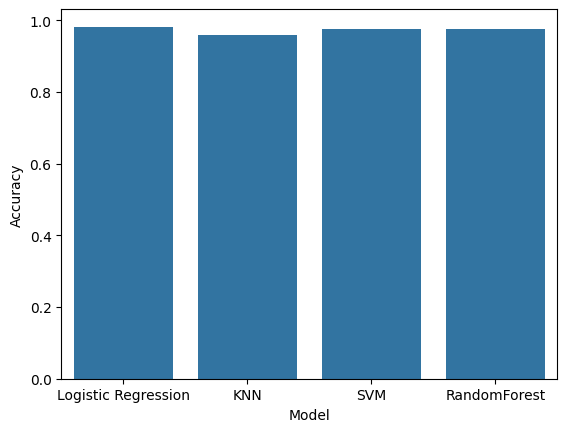

In [ ]:
import seaborn as sns
sns.barplot(x = 'Model' , y = 'Accuracy' , data = results)

Q8. Hyperparameter Tuning Comparison

Take Random Forest.

Run

Manual Loop

↓

GridSearchCV

↓

RandomizedSearchCV

Compare

Accuracy
Time Taken
Best Parameters

In [ ]:
model = RandomForestClassifier()

In [ ]:
params = {
    'n_estimators' : [100 , 200 , 300],
    'max_depth' : [10 , 20 , 30],
    'criterion' : ['gini' , 'entropy']
}

In [ ]:
grid = GridSearchCV(model , param_grid = params)
st = t.time()
grid.fit(X_train , y_train)
end = t.time()
print('CPU time' , end - st)
grid.predict(X_test)
print(accuracy_score(y_test , y_pred))
print(grid.best_params_)

CPU time 69.85485792160034
0.9649122807017544
{'criterion': 'gini', 'max_depth': 10, 'n_estimators': 100}


Q9. Pipeline + Feature Selection

Pipeline

StandardScaler

↓

SelectKBest

↓

Logistic Regression

Tune

k = [5,10,15]

Find the best value of k.

In [ ]:
from sklearn.feature_selection import SelectKBest

In [ ]:
pipe = Pipeline([
    ('scaler' , StandardScaler()),
    ('skb' , SelectKBest()),
    ('lg' , LogisticRegression())
])

In [ ]:
params = {
    'skb__k' : [5,10,15]
}

In [ ]:
grid = GridSearchCV(pipe , param_grid = params)
grid.fit(X_train ,y_train)
print(grid.best_params_)
print(grid.best_score_)

{'skb__k': 15}
0.9573417721518988


Q10. Polynomial Features

Pipeline

PolynomialFeatures

↓

StandardScaler

↓

Linear Regression

Try

Degree

2

3

4

Compare

MAE

RMSE

R²

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

In [ ]:
pipe = Pipeline([
    ('poly' , PolynomialFeatures()),
    ('scaler' , StandardScaler()),
    ('lg' , LinearRegression())
])

In [ ]:
params = {
    'poly__degree' : [2,3,4]
}

In [ ]:
grid = GridSearchCV(pipe , param_grid = params)
grid.fit(X_train , y_train)
print(grid.best_params_)
print(grid.best_score_)
print(mean_absolute_error(y_test , y_pred))
print(root_mean_squared_error(y_test , y_pred))
print(r2_score(y_test , y_pred))

{'poly__degree': 3}
-69.09715761301705
0.03508771929824561
0.1873171623163388
0.8492063492063492
